# Geometry Dataset Balance Check

This notebook visualizes label distribution from `dataset/data/diagrams_filter.json`
and reports simple class-balance metrics.

In [1]:
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
DATA_PATH = Path("../dataset/data/diagrams_filter.json")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Cannot find file: {DATA_PATH.resolve()}")

df = pd.read_json(DATA_PATH)
df = df.fillna({"caption": "", "caption_vn": ""})
df.head()

,image,caption,id,caption_vn
0,images/img_1.png,"triangle ABC, angle ABC = 90, angle BAC = 45, ...",1,"Tam giác ABC, góc ABC = 90, góc BAC = 45, góc ..."
1,images/img_100000.png,"triangle ABC, angle ABC = 90, angle BAC = 45, ...",100000,"Tam giác ABC, góc ABC = 90, góc BAC = 45, góc ..."
2,images/img_100010.png,"circle O, point A is on circle O",100010,"Đường tròn O, điểm A nằm trên đường tròn O"
3,images/img_100011.png,"triangle ABC, angle ABC = 90, angle BAC = 60, ...",100011,"Tam giác ABC, góc ABC = 90, góc BAC = 60, góc ..."
4,images/img_100022.png,"triangle ABC, AB = AC, point D is on segment A...",100022,"Tam giác ABC, AB = AC, điểm D nằm trên đoạn th..."


In [3]:
import re

def extract_categories(caption: str, keywords: list[str]) -> list[str]:
    text = str(caption).strip().lower()
    if not text:
        return ["unknown"]
    found = [kw for kw in keywords if kw in text]
    return sorted(set(found)) if found else ["unknown"]

RELATION_PATTERNS = {
    "parallel": [r"\bparallel\b", r"//"],
    "perpendicular": [r"\bperpendicular\b", r"⊥", r"vuong goc"],
    "equal": [r"=" , r"\bequal\b", r"bang nhau"],
    "midpoint": [r"\bmidpoint\b", r"trung diem"],
    "bisector": [r"\bbisector\b", r"phan giac", r"trung truc"],
    "on_segment": [r"\bon segment\b", r"nam tren doan"],
    "on_line": [r"\bon line\b", r"nam tren duong thang"],
    "on_circle": [r"\bon circle\b", r"nam tren duong tron"],
    "incircle": [r"\bincircle\b", r"noi tiep"],
    "circumcircle": [r"\bcircumcircle\b", r"ngoai tiep"],
    "diameter": [r"\bdiameter\b", r"duong kinh"],
    "tangent": [r"\btangent\b", r"tiep tuyen"],
    "intersect": [r"\bintersect\b", r"giao nhau"],
}

def extract_relations(caption: str, relation_patterns: dict[str, list[str]]) -> list[str]:
    text = str(caption).strip().lower()
    if not text:
        return ["none"]

    matched = []
    for rel, patterns in relation_patterns.items():
        if any(re.search(p, text) for p in patterns):
            matched.append(rel)
    return sorted(set(matched)) if matched else ["none"]

KEYWORDS = [
    "triangle", "circle", "rectangle", "square", "rhombus", "trapezoid",
    "quadrilateral", "parallelogram"
]

df["categories"] = df["caption"].map(lambda x: extract_categories(x, KEYWORDS))
df["relations"] = df["caption"].map(lambda x: extract_relations(x, RELATION_PATTERNS))
df["num_clauses"] = df["caption"].map(lambda x: str(x).count(",") + 1 if str(x).strip() else 0)
df["num_categories"] = df["categories"].map(len)
df["num_relations"] = df["relations"].map(len)

for kw in KEYWORDS:
    df[f"kw_{kw}"] = df["categories"].map(lambda arr: int(kw in arr))

for rel in RELATION_PATTERNS:
    df[f"rel_{rel}"] = df["relations"].map(lambda arr: int(rel in arr))

df[["id", "caption", "categories", "relations", "num_clauses", "num_categories", "num_relations"]].head()

,id,caption,categories,relations,num_clauses,num_categories,num_relations
0,1,"triangle ABC, angle ABC = 90, angle BAC = 45, ...","[circle, triangle]","[diameter, equal, midpoint]",9,2,3
1,100000,"triangle ABC, angle ABC = 90, angle BAC = 45, ...",[triangle],[equal],5,1,1
2,100010,"circle O, point A is on circle O",[circle],[on_circle],2,1,1
3,100011,"triangle ABC, angle ABC = 90, angle BAC = 60, ...","[circle, triangle]","[equal, incircle]",6,2,2
4,100022,"triangle ABC, AB = AC, point D is on segment A...",[triangle],"[bisector, equal, on_segment, parallel, perpen...",6,1,5


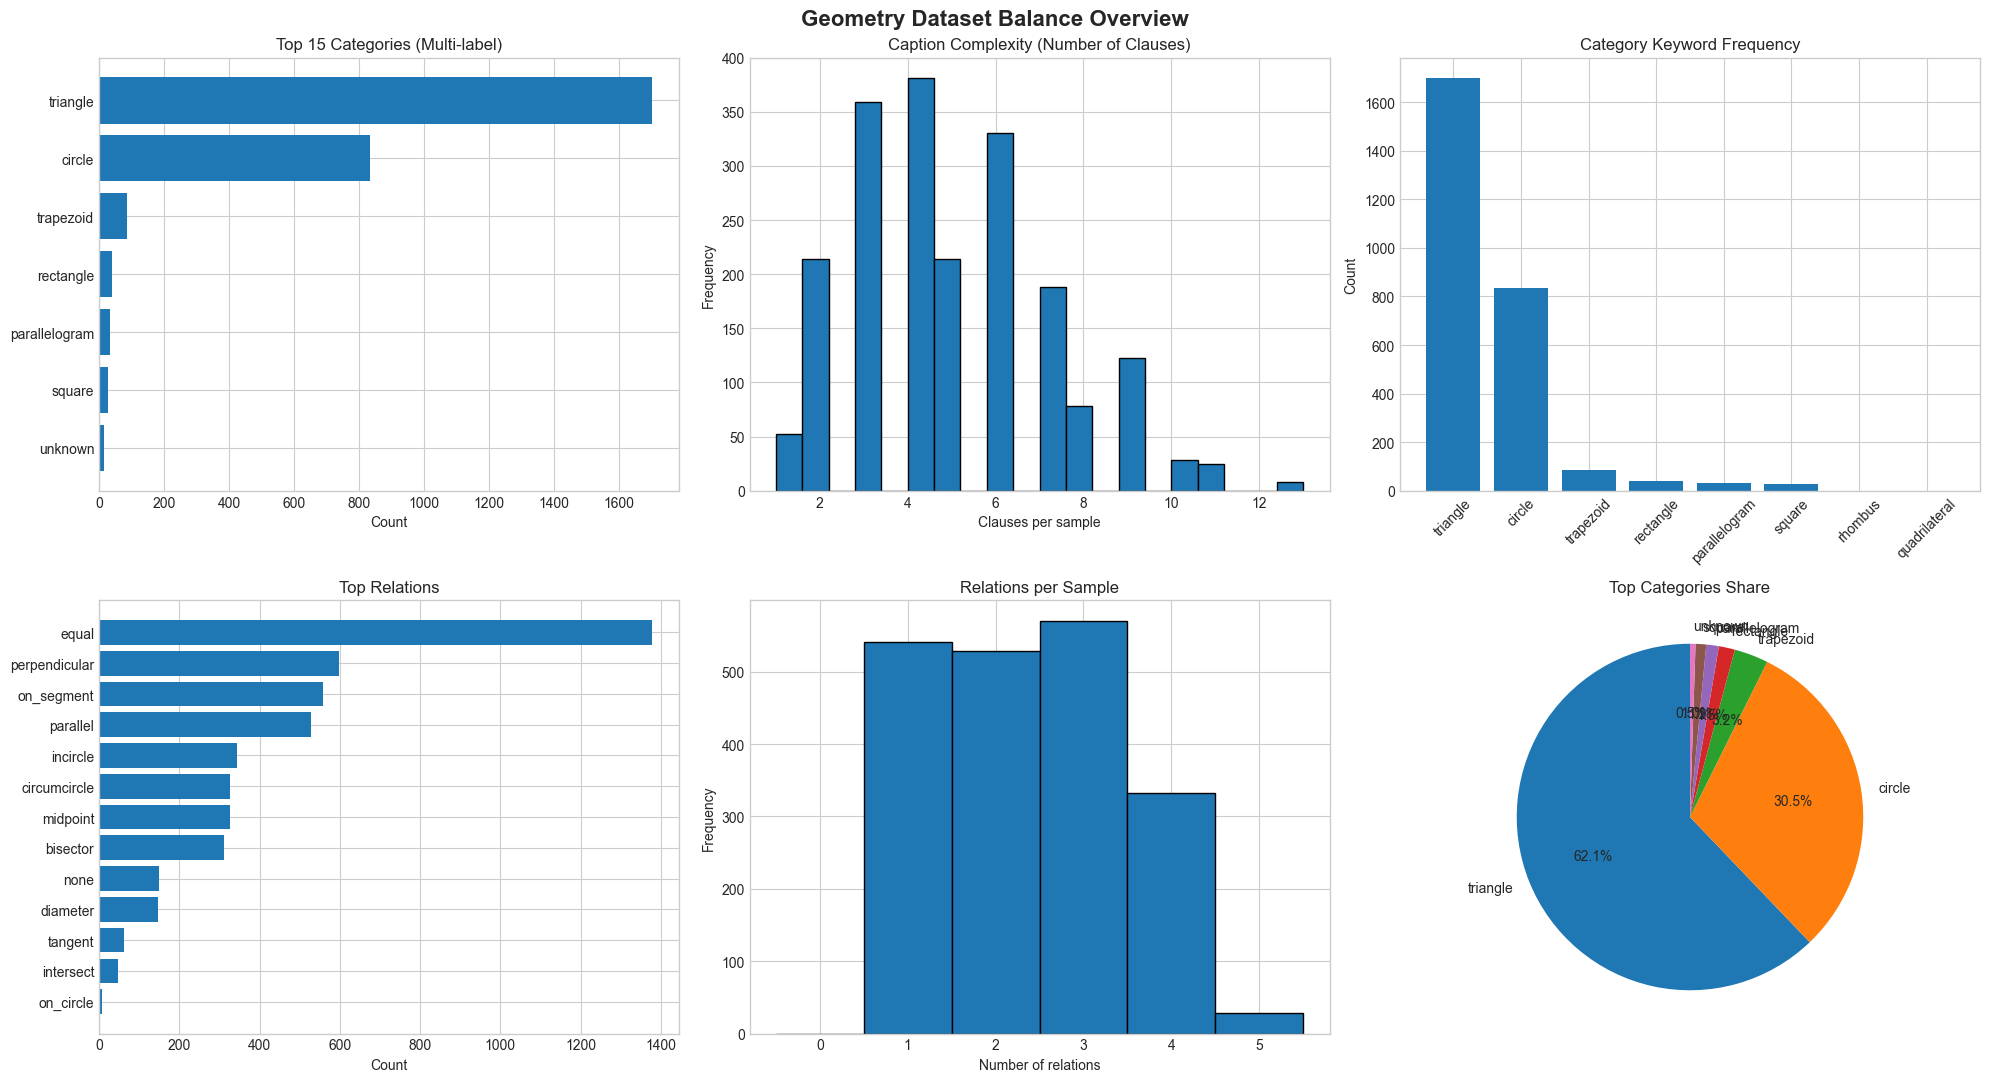

In [4]:
category_counts = df["categories"].explode().value_counts()
relation_counts = df["relations"].explode().value_counts()

top_categories = category_counts.head(15).sort_values()
top_relations = relation_counts.head(15).sort_values()

keyword_counts = {kw: int(df[f"kw_{kw}"].sum()) for kw in KEYWORDS}
keyword_counts = dict(sorted(keyword_counts.items(), key=lambda x: x[1], reverse=True))

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle("Geometry Dataset Balance Overview", fontsize=16, fontweight="bold")

# 1) Top categories (multi-label)
axes[0, 0].barh(top_categories.index, top_categories.values)
axes[0, 0].set_title("Top 15 Categories (Multi-label)")
axes[0, 0].set_xlabel("Count")

# 2) Clause complexity
axes[0, 1].hist(df["num_clauses"], bins=20, edgecolor="black")
axes[0, 1].set_title("Caption Complexity (Number of Clauses)")
axes[0, 1].set_xlabel("Clauses per sample")
axes[0, 1].set_ylabel("Frequency")

# 3) Keyword coverage from your category list
axes[0, 2].bar(keyword_counts.keys(), keyword_counts.values())
axes[0, 2].set_title("Category Keyword Frequency")
axes[0, 2].set_ylabel("Count")
axes[0, 2].tick_params(axis="x", rotation=45)

# 4) Top relations
axes[1, 0].barh(top_relations.index, top_relations.values)
axes[1, 0].set_title("Top Relations")
axes[1, 0].set_xlabel("Count")

# 5) Number of relations per sample
bins_rel = range(0, int(df["num_relations"].max()) + 2)
axes[1, 1].hist(df["num_relations"], bins=bins_rel, edgecolor="black", align="left")
axes[1, 1].set_title("Relations per Sample")
axes[1, 1].set_xlabel("Number of relations")
axes[1, 1].set_ylabel("Frequency")

# 6) Dominance view (top 8 categories + others)
top8 = category_counts.head(8)
others = int(category_counts.iloc[8:].sum())
labels = list(top8.index) + (["others"] if others > 0 else [])
sizes = list(top8.values) + ([others] if others > 0 else [])
axes[1, 2].pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
axes[1, 2].set_title("Top Categories Share")

plt.tight_layout()
plt.show()

In [5]:
def normalized_entropy(counts: np.ndarray) -> float:
    probs = counts / counts.sum()
    probs = probs[probs > 0]
    if len(probs) <= 1:
        return 0.0
    h = -np.sum(probs * np.log(probs))
    return float(h / np.log(len(probs)))

category_arr = category_counts.values.astype(float)
relation_arr = relation_counts.values.astype(float)

cat_max = category_arr.max() if len(category_arr) else 0
cat_min = category_arr.min() if len(category_arr) else 0
cat_imbalance_ratio = (cat_max / cat_min) if cat_min > 0 else np.inf
cat_entropy_score = normalized_entropy(category_arr) if len(category_arr) else 0.0

rel_max = relation_arr.max() if len(relation_arr) else 0
rel_min = relation_arr.min() if len(relation_arr) else 0
rel_imbalance_ratio = (rel_max / rel_min) if rel_min > 0 else np.inf
rel_entropy_score = normalized_entropy(relation_arr) if len(relation_arr) else 0.0

print(f"Total samples: {len(df)}")
print(f"Number of unique categories: {category_counts.size}")
print(f"Number of unique relations: {relation_counts.size}")
print(f"Avg categories/sample: {df['num_categories'].mean():.2f}")
print(f"Avg relations/sample: {df['num_relations'].mean():.2f}")

print("\nCategory balance:")
print(f"Largest category count: {int(cat_max)}")
print(f"Smallest category count: {int(cat_min)}")
print(f"Imbalance ratio (max/min): {cat_imbalance_ratio:.2f}")
print(f"Normalized entropy [0,1]: {cat_entropy_score:.3f}")

print("\nRelation balance:")
print(f"Largest relation count: {int(rel_max)}")
print(f"Smallest relation count: {int(rel_min)}")
print(f"Imbalance ratio (max/min): {rel_imbalance_ratio:.2f}")
print(f"Normalized entropy [0,1]: {rel_entropy_score:.3f}")

if cat_imbalance_ratio <= 2 and cat_entropy_score >= 0.90:
    cat_verdict = "Relatively balanced"
elif cat_imbalance_ratio <= 5 and cat_entropy_score >= 0.75:
    cat_verdict = "Moderately imbalanced"
else:
    cat_verdict = "Strongly imbalanced"

if rel_imbalance_ratio <= 2 and rel_entropy_score >= 0.90:
    rel_verdict = "Relatively balanced"
elif rel_imbalance_ratio <= 5 and rel_entropy_score >= 0.75:
    rel_verdict = "Moderately imbalanced"
else:
    rel_verdict = "Strongly imbalanced"

print(f"Category balance verdict: {cat_verdict}")
print(f"Relation balance verdict: {rel_verdict}")

print("\nTop 20 categories:")
display(category_counts.head(20).to_frame("count"))

print("\nTop 20 relations:")
display(relation_counts.head(20).to_frame("count"))

Total samples: 2000
Number of unique categories: 7
Number of unique relations: 13
Avg categories/sample: 1.37
Avg relations/sample: 2.39

Category balance:
Largest category count: 1699
Smallest category count: 14
Imbalance ratio (max/min): 121.36
Normalized entropy [0,1]: 0.491

Relation balance:
Largest relation count: 1377
Smallest relation count: 6
Imbalance ratio (max/min): 229.50
Normalized entropy [0,1]: 0.847
Category balance verdict: Strongly imbalanced
Relation balance verdict: Strongly imbalanced

Top 20 categories:


,count
categories,
triangle,1699
circle,834
trapezoid,87
rectangle,41
parallelogram,32
square,27
unknown,14



Top 20 relations:


,count
relations,
equal,1377
perpendicular,598
on_segment,557
parallel,527
incircle,344
circumcircle,327
midpoint,326
bisector,312
none,149
